# Measured vs Simulated SoH — 7 confirmed Phase 2 anchors

For each of the 7 Phase 2 keep cells (CALB 0003/0009/0010/0015 · EVE 0004 · REPT 0007/0057), rerun the PyBaMM simulation using:
- Cell's **BOL** parameters from Phase 1 (`configs/bol_params/{make}_{cell}.yaml`)
- Cell's **fitted degradation θ** from Phase 2 (`configs/deg_params/{make}_{cell}.yaml`)
- Cell's **own experiment protocol** (`configs/cohort_experiment_protocols.yaml`)

Overlay against the measured Longterm SoH. RMSE printed per panel must match the yaml's `best_rmse_pp`.

This is the **SoH-shape validation** Stage B said was missing — eyeball whether fits reproduce fade *shape* (curvature, knee timing), not just endpoint RMSE.

In [1]:
import sys, time, yaml, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
HERE = Path('/home/hj/Desktop/PINNs/Voltaris/Data_Exploration')
sys.path.insert(0, str(HERE))
import phase2_de_fit as p2

ANCHORS = [
    ('CALB', '0003'), ('CALB', '0009'), ('CALB', '0010'), ('CALB', '0015'),
    ('EVE',  '0004'),
    ('REPT', '0007'), ('REPT', '0057'),
]
MAKE_COLOR = {'CALB': '#c94a3c', 'EVE': '#4dab5c', 'REPT': '#3c7cc9'}
print(f'{len(ANCHORS)} anchor cells to overlay')

7 anchor cells to overlay


In [2]:
# For each anchor: run simulate_soh_trajectory with the SAVED θ.
def _saved_theta_log(deg_yaml_path):
    d = yaml.safe_load(Path(deg_yaml_path).read_text())
    fp = d['fitted_params']
    order = ['k_SEI', 'V_SEI', 'D_SEI_solvent', 'k_plating', 'k_LAM_negative']
    enc = {'k_SEI':'log10','V_SEI':'linear','D_SEI_solvent':'log10',
           'k_plating':'log10','k_LAM_negative':'log10'}
    out = [np.log10(float(fp[k]['value'])) if enc[k]=='log10' else float(fp[k]['value']) for k in order]
    return np.array(out, dtype=float), d.get('best_rmse_pp', np.nan)

results = []
for make, cell in ANCHORS:
    t0 = time.time()
    print(f'  {make} {cell} ...', end='', flush=True)
    deg = f'/home/hj/Desktop/PINNs/configs/deg_params/{make}_{cell}.yaml'
    theta_log, saved_rmse = _saved_theta_log(deg)
    ctx = p2.load_cell_context(make, cell)
    pv = p2.build_pybamm_parameters(ctx['bol'])
    pv = p2.apply_deg_params(pv, **p2._theta_from_log(theta_log))
    soh_sim = p2.simulate_soh_trajectory(pv, ctx['experiment_steps'],
                                          n_cycles=ctx['cycles_measured'],
                                          nominal_capacity_Ah=ctx['nominal_capacity_Ah'])
    meas = np.asarray(ctx['measured_soh_array'], dtype=float)
    meas_norm = meas / meas[0]
    results.append(dict(make=make, cell=cell,
                        theta_log=theta_log, saved_rmse=saved_rmse,
                        soh_sim=soh_sim, meas_norm=meas_norm,
                        protocol=ctx.get('protocol_id','?'),
                        wall_s=time.time()-t0))
    print(f' {results[-1]["wall_s"]:.1f}s   sim[-1]={soh_sim[-1]:.3f}   meas[-1]={meas_norm[-1]:.3f}   saved RMSE={saved_rmse:.3f} pp')
print('done')

  CALB 0003 ...

 17.6s   sim[-1]=0.937   meas[-1]=0.938   saved RMSE=0.826 pp
  CALB 0009 ...

 15.6s   sim[-1]=0.940   meas[-1]=0.937   saved RMSE=0.456 pp
  CALB 0010 ...

 15.9s   sim[-1]=0.957   meas[-1]=0.954   saved RMSE=0.308 pp
  CALB 0015 ...

 17.0s   sim[-1]=0.978   meas[-1]=0.977   saved RMSE=0.207 pp
  EVE 0004 ...

 6.8s   sim[-1]=1.000   meas[-1]=1.002   saved RMSE=0.692 pp
  REPT 0007 ...

 8.2s   sim[-1]=0.974   meas[-1]=0.974   saved RMSE=0.055 pp
  REPT 0057 ...

 9.4s   sim[-1]=0.978   meas[-1]=0.978   saved RMSE=0.063 pp
done


## SoH overlay per anchor (measured vs fitted-θ simulation)

Coloured line: measured (cycle-1 normalised). Black dashed: simulated with fitted θ (cycle-1 normalised). Perfect fit → lines coincide.

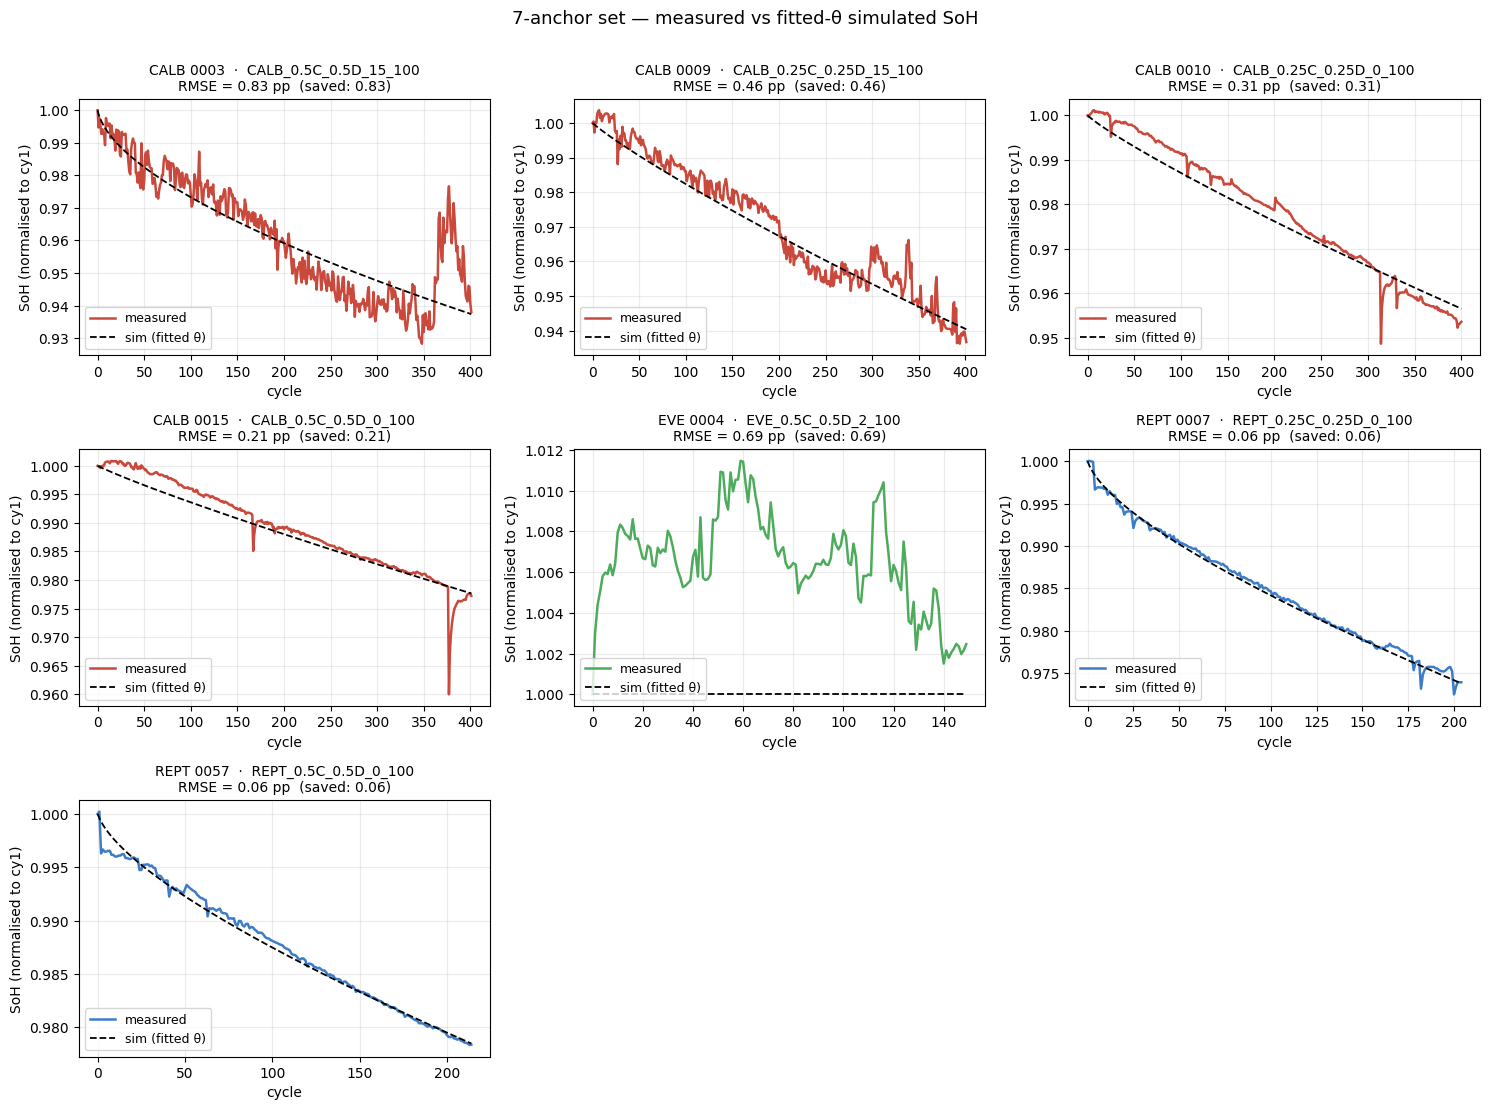

In [3]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11), sharey=False)
axes = axes.ravel()
for i, r in enumerate(results):
    ax = axes[i]
    color = MAKE_COLOR[r['make']]
    n_meas = len(r['meas_norm']); n_sim = len(r['soh_sim'])
    n = min(n_meas, n_sim)
    ax.plot(np.arange(n_meas), r['meas_norm'], color=color, lw=1.8, label='measured')
    ax.plot(np.arange(n_sim),  r['soh_sim'],   color='k', ls='--', lw=1.3, label='sim (fitted θ)')
    resid = r['soh_sim'][:n] - r['meas_norm'][:n]
    rmse_pp = float(np.sqrt(np.nanmean(resid**2)) * 100)
    ax.set_title(f"{r['make']} {r['cell']}  ·  {r['protocol']}\n"
                 f"RMSE = {rmse_pp:.2f} pp  (saved: {r['saved_rmse']:.2f})",
                 fontsize=10)
    ax.set_xlabel('cycle'); ax.set_ylabel('SoH (normalised to cy1)')
    ax.grid(alpha=0.25); ax.legend(fontsize=9, loc='lower left')
for j in range(len(results), len(axes)):
    axes[j].axis('off')
fig.suptitle('7-anchor set — measured vs fitted-θ simulated SoH', y=1.005, fontsize=13)
fig.tight_layout()
plt.show()

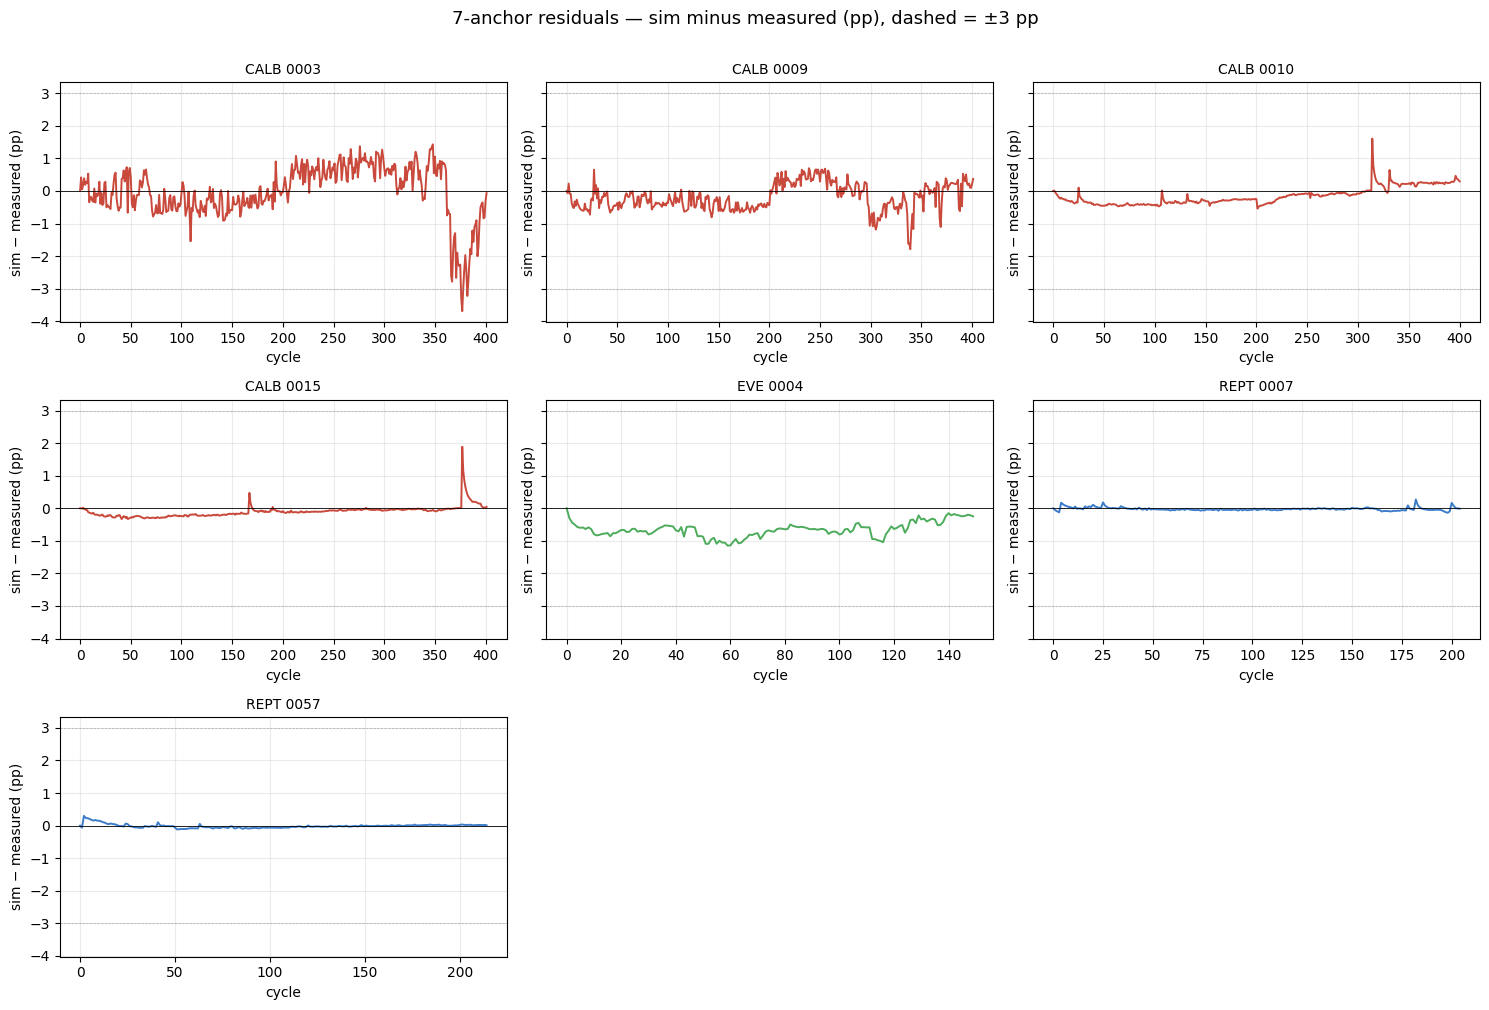

In [4]:
# Residual (sim − measured) per cycle, in pp; ±3 pp reference lines.
fig, axes = plt.subplots(3, 3, figsize=(15, 10), sharey=True)
axes = axes.ravel()
for i, r in enumerate(results):
    ax = axes[i]
    color = MAKE_COLOR[r['make']]
    n = min(len(r['soh_sim']), len(r['meas_norm']))
    resid_pp = (r['soh_sim'][:n] - r['meas_norm'][:n]) * 100
    ax.plot(np.arange(n), resid_pp, color=color, lw=1.4)
    ax.axhline(0, color='k', lw=0.6)
    ax.axhline(+3, color='grey', lw=0.5, ls='--', alpha=0.6)
    ax.axhline(-3, color='grey', lw=0.5, ls='--', alpha=0.6)
    ax.set_title(f"{r['make']} {r['cell']}", fontsize=10)
    ax.set_xlabel('cycle'); ax.set_ylabel('sim − measured (pp)')
    ax.grid(alpha=0.25)
for j in range(len(results), len(axes)):
    axes[j].axis('off')
fig.suptitle('7-anchor residuals — sim minus measured (pp), dashed = ±3 pp', y=1.005, fontsize=13)
fig.tight_layout()
plt.show()

In [5]:
rows = []
for r in results:
    n = min(len(r['soh_sim']), len(r['meas_norm']))
    resid = r['soh_sim'][:n] - r['meas_norm'][:n]
    rows.append({
        'make': r['make'], 'cell': r['cell'], 'protocol': r['protocol'],
        'n_meas': len(r['meas_norm']), 'n_sim': len(r['soh_sim']),
        'coverage': f'{n/len(r["meas_norm"])*100:.0f}%',
        'sim_final_SoH': round(float(r['soh_sim'][-1]), 4),
        'meas_final_SoH': round(float(r['meas_norm'][-1]), 4),
        'RMSE_pp_computed': round(float(np.sqrt(np.nanmean(resid**2)) * 100), 3),
        'RMSE_pp_saved': round(float(r['saved_rmse']), 3),
        'wall_s': round(r['wall_s'], 1),
    })
df = pd.DataFrame(rows)
print(df.to_string(index=False))
df.to_csv(HERE / 'phase2_soh_overlays_summary.csv', index=False)

make cell                protocol  n_meas  n_sim coverage  sim_final_SoH  meas_final_SoH  RMSE_pp_computed  RMSE_pp_saved  wall_s
CALB 0003   CALB_0.5C_0.5D_15_100     402    402     100%         0.9374          0.9380             0.826          0.826    17.6
CALB 0009 CALB_0.25C_0.25D_15_100     402    402     100%         0.9404          0.9367             0.456          0.456    15.6
CALB 0010  CALB_0.25C_0.25D_0_100     401    401     100%         0.9566          0.9536             0.308          0.308    15.9
CALB 0015    CALB_0.5C_0.5D_0_100     402    402     100%         0.9777          0.9772             0.207          0.207    17.0
 EVE 0004     EVE_0.5C_0.5D_2_100     150    150     100%         1.0000          1.0025             0.692          0.692     6.8
REPT 0007  REPT_0.25C_0.25D_0_100     205    205     100%         0.9738          0.9739             0.055          0.055     8.2
REPT 0057    REPT_0.5C_0.5D_0_100     215    215     100%         0.9785          0.9784  